In [2]:
import sys
import os
import importlib
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

import utils.color_utils as color_utils
importlib.reload(color_utils)
ColorLibrary = color_utils.ColorLibrary

cl = ColorLibrary.from_categorized_csv('../datasets/categorized_colors.csv')
print(f"Loaded {len(cl.categories)} categories:")
cl.summary()

Loaded 13 categories:
red: 20 colors
orange: 19 colors
yellow: 34 colors
green: 44 colors
blue: 31 colors
violet: 11 colors
purple: 25 colors
white: 6 colors
gray: 20 colors
black: 7 colors
pink: 25 colors
brown: 27 colors
olive: 17 colors


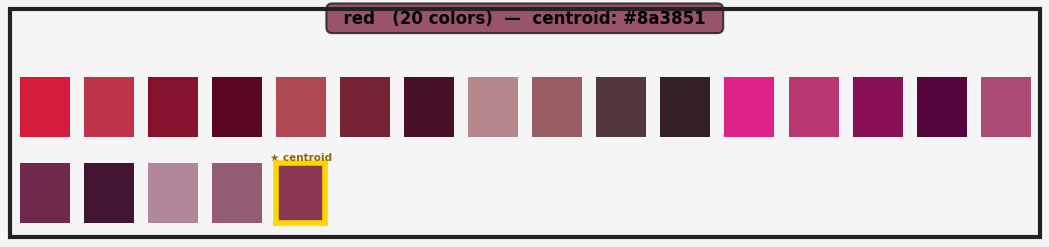

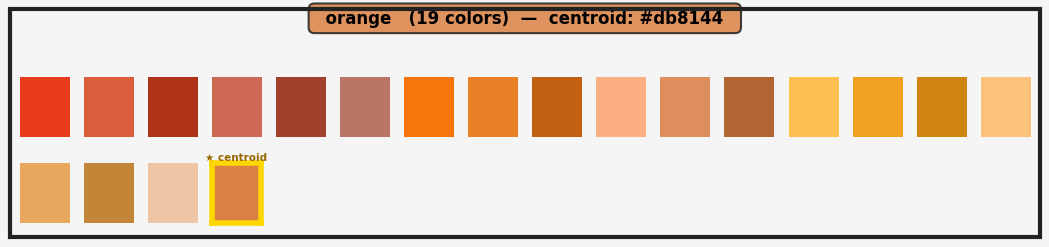

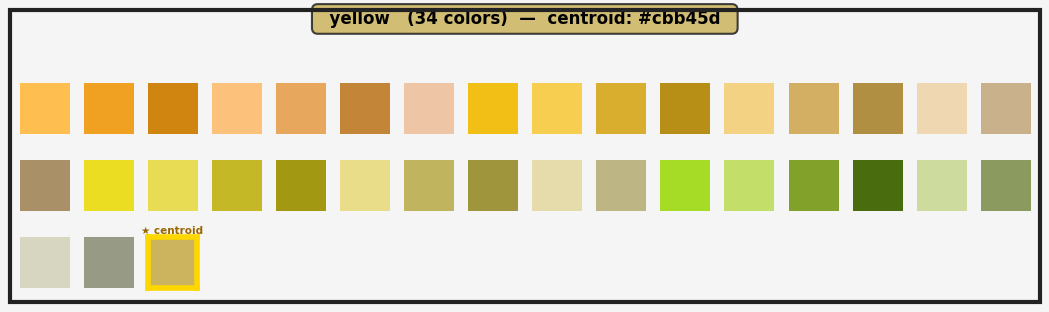

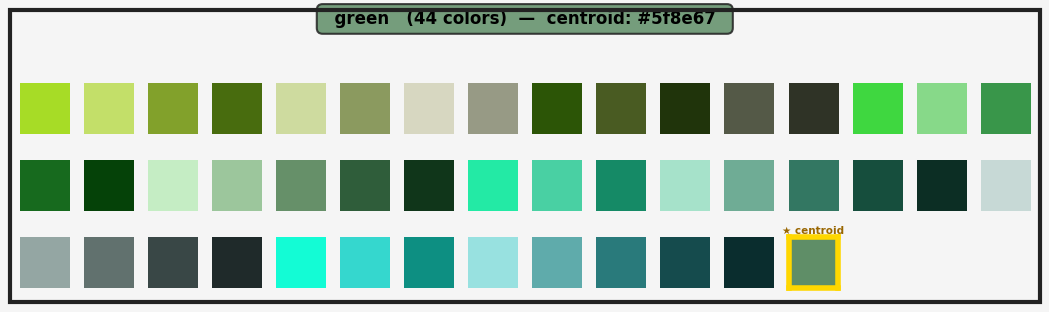

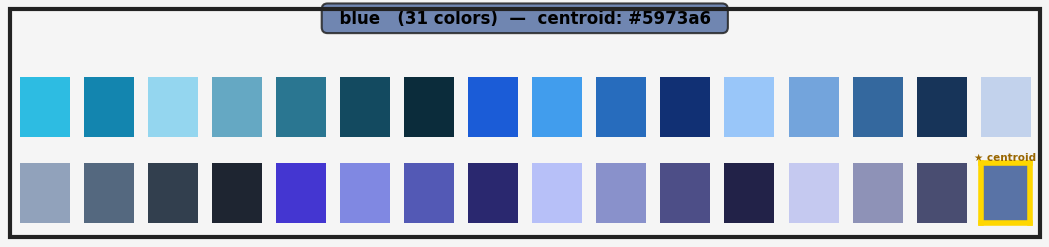

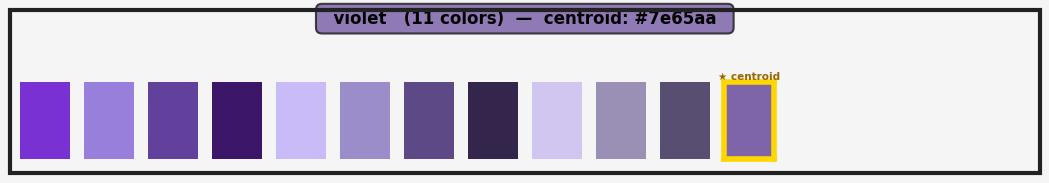

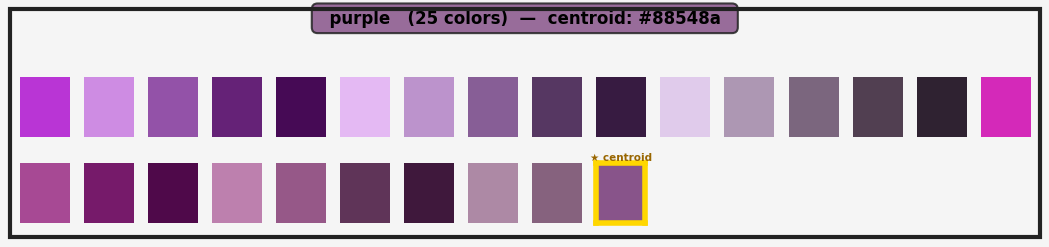

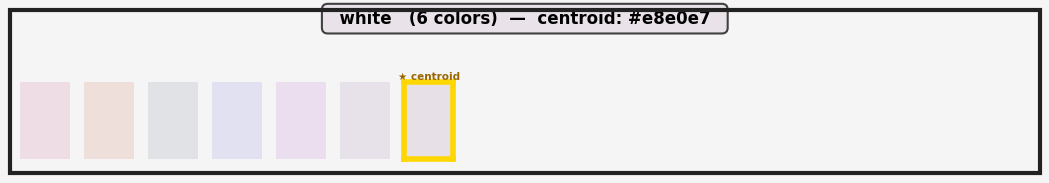

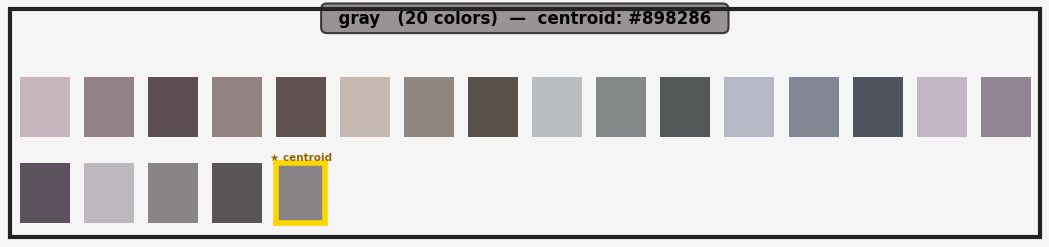

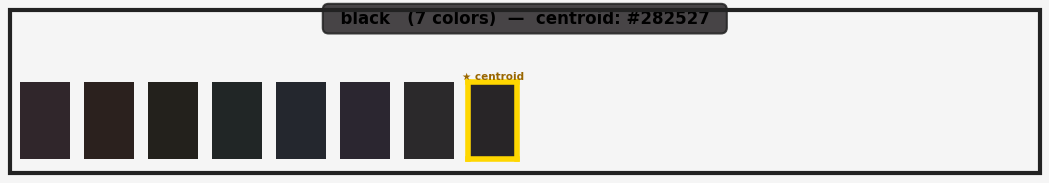

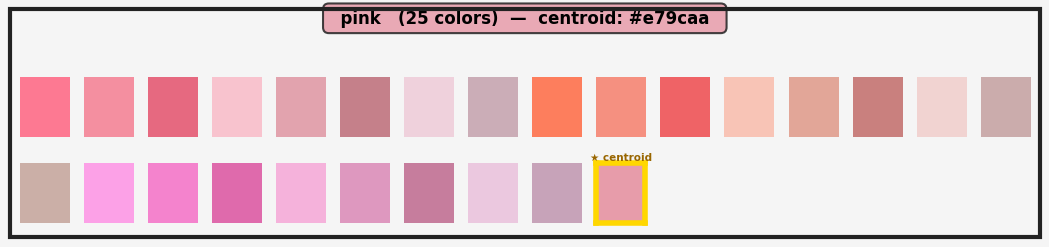

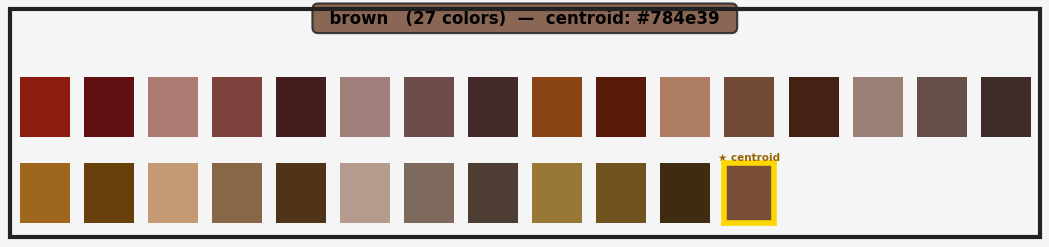

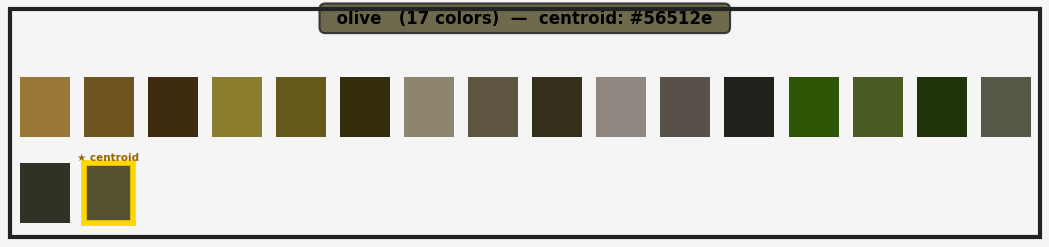

In [ ]:
import math
import matplotlib.pyplot as plt

NCOLS = 16

for cat in cl.categories:
    hex_list = cl.color_library[cat]
    centroid_lab = cl.get_category_centroid(cat)
    _, centroid_hex = cl._lab_to_hex(*centroid_lab)

    all_swatches = hex_list + [centroid_hex]
    n = len(all_swatches)
    nrows = math.ceil(n / NCOLS)

    fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 0.5, nrows * 0.5 + 0.6))
    axes = axes.flatten() if nrows * NCOLS > 1 else [axes]

    for i, ax in enumerate(axes):
        if i < len(hex_list):
            h = hex_list[i].lstrip('#')
            ax.imshow([[[int(h[j:j+2], 16)/255 for j in (0,2,4)]]])
            ax.axis('off')
        elif i == len(hex_list):
            h = centroid_hex.lstrip('#')
            ax.imshow([[[int(h[j:j+2], 16)/255 for j in (0,2,4)]]])
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('gold')
                spine.set_linewidth(3)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.axis('off')

    fig.suptitle(f'{cat}  ({len(hex_list)} colors)  |  centroid: {centroid_hex}', fontsize=9, y=1.01)
    plt.tight_layout()
    plt.show()
